<p class="h1">ECE 447 - Notebook 17</p>
<p class="h2">Convolution</p>

In [1]:
import numpy as np                 # import numpy
import scipy.signal as spsignal
import matplotlib.pyplot as plt    # import matplotlib plot
import matplotlib.image as matimg  # import matplotlib image

In [2]:
def vis_images(kernel, img, img_proc, cmap="gray"):
    plt.figure(figsize=(15,5))
    plt.subplot(131)
    plt.imshow(kernel, cmap=cmap)
    plt.title("kernel")
    plt.subplot(132)
    plt.imshow(img, cmap=cmap)
    plt.title("image")
    plt.subplot(133)
    plt.imshow(img_proc, cmap=cmap)
    plt.title("filtered image")
    plt.show()
    return

def visualize_loss_acc(train_loss_all, test_loss_all, train_acc_all, test_acc_all):
    plt.figure(figsize=(12,3))
    plt.subplot(121)
    plt.plot(train_loss_all, color="red", label="Train")
    plt.plot(test_loss_all, color="green", label="Test")
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.subplot(122)
    plt.plot(train_acc_all, color="red", label="Train")
    plt.plot(test_acc_all, color="green", label="Test")
    plt.legend()
    plt.title("Accuracy [%]")
    plt.xlabel("Epochs")
    plt.ylim(0,100)
    plt.show()
    return

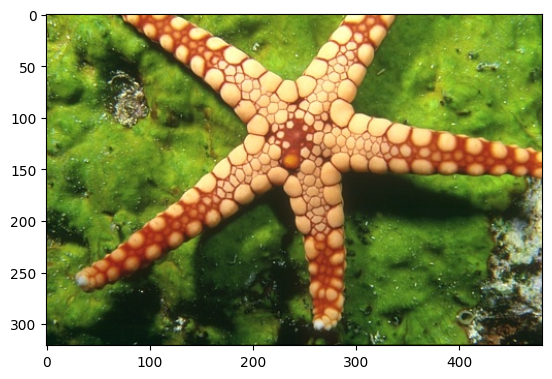

In [3]:
# load image
img_path = "data/img/12003.jpg"
img_color = matimg.imread(img_path)

# visualize image
plt.imshow(img_color)
plt.show()

# device = "cpu" # for cpu
# device = "cuda:0" # for nvidia
device = "mps:0" # for mac with gpu

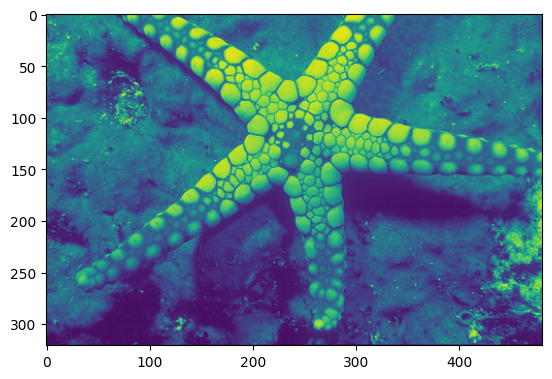

In [4]:
# make grayscale

img = np.mean(img_color, axis=-1)

plt.imshow(img)
plt.show()

In [5]:
# create Gaussian 2D function
def G2D(x, y, sigma=1):
    return (1.0 / (2 * np.pi * (sigma**2))) * np.exp(-(1.0 / (2 * (sigma**2))) * (x**2 + y**2))

In [6]:
# create receptive field
def create_receptive_field(func, kernel_size=10):
    receptive_field = np.zeros((kernel_size,kernel_size))
    for i in range(kernel_size):
        for j in range(kernel_size):
            x = i-kernel_size/2
            y = j-kernel_size/2
            receptive_field[i, j] = func(x, y);
    return receptive_field

sigma = 5
kernel_size = 25
filterFunc = lambda x,y:G2D(x,y,sigma)
kernel = create_receptive_field(filterFunc, kernel_size)

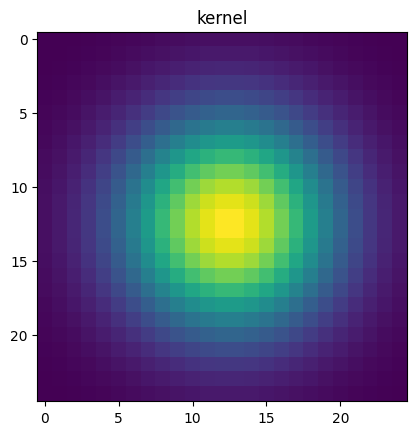

(321, 481)


In [7]:
# visualize the receptive field
plt.imshow(kernel)
plt.title("kernel")
plt.show()

print(img.shape)

In [8]:
# perform convolution of img * kernel.
img_proc = spsignal.convolve2d(img, kernel)
img_proc[img_proc>255] = 255
img_proc[img_proc<0] = 0

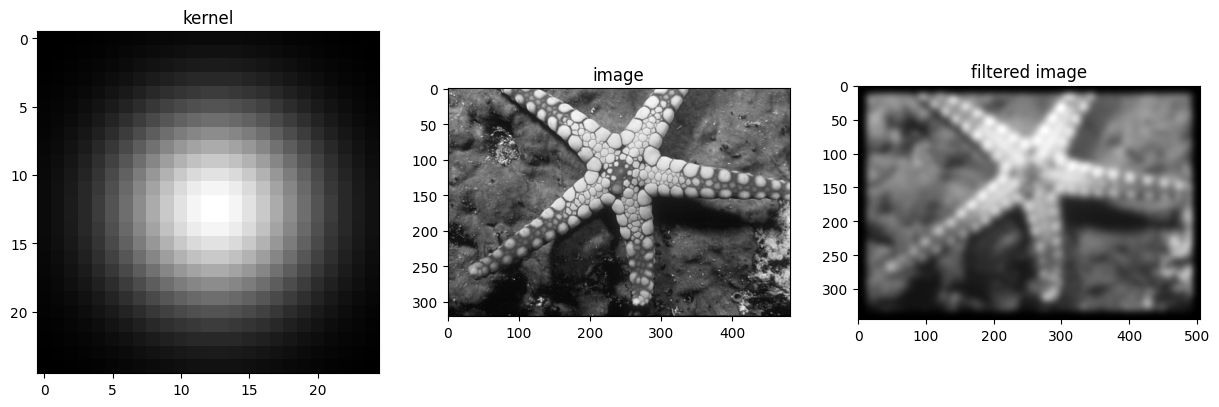

In [9]:
# visualize kernel, img, and filtered img

vis_images(kernel, img, img_proc, cmap="gray")

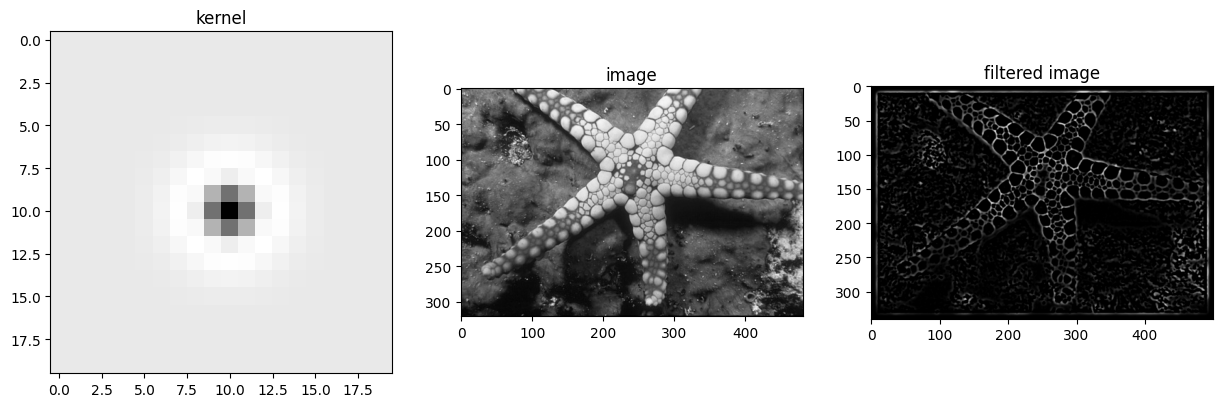

In [10]:
# create difference of Gaussian filters
def diffG2D(sigma1=1, sigma2=5):
    return lambda x,y:G2D(x,y,sigma1) - G2D(x,y,sigma2)

# create receptive field
sigma1 = 2
sigma2 = 1
kernel_size = 20
filterFunc = diffG2D(sigma1, sigma2)
kernel = create_receptive_field(filterFunc, kernel_size)

# perform convolution of img * kernel.
img_proc = spsignal.convolve2d(img, kernel)
img_proc[img_proc>255] = 255
img_proc[img_proc<0] = 0

# visualize
vis_images(kernel, img, img_proc, cmap="gray")

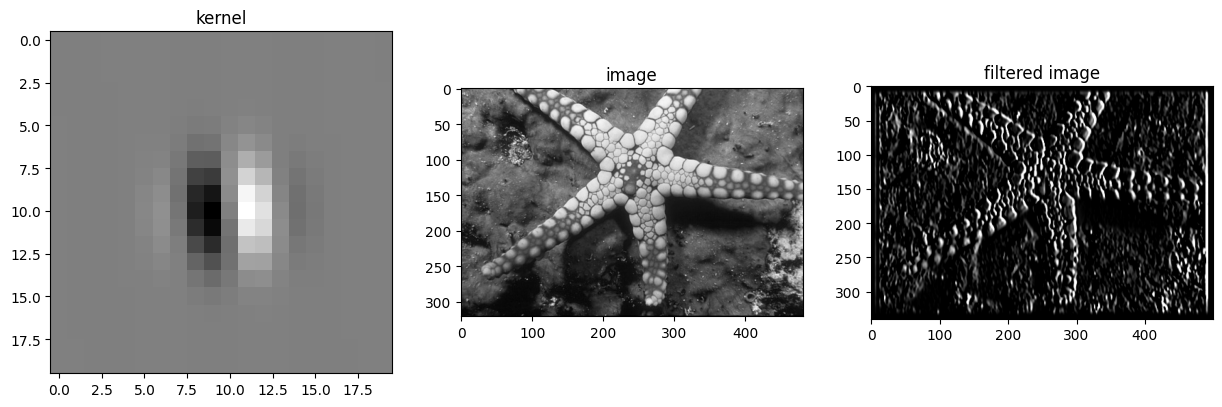

In [44]:
# create Gabor filters
def Gabor(x, y, sigma, theta, f):
    return np.exp(-(x**2 + y**2)/(2 * sigma**2)) * np.sin(2 * np.pi * f * (x * np.cos(theta)+ y * np.sin(theta)))

# create receptive field
sigma = 2
theta = np.pi/20
f = 1
kernel_size = 20
filterFunc = lambda x,y:Gabor(x, y, sigma, theta, f)
kernel = create_receptive_field(filterFunc, kernel_size)

# perform convolution of img * kernel.
img_proc = spsignal.convolve2d(img, kernel)
img_proc[img_proc>255] = 255
img_proc[img_proc<0] = 0

vis_images(kernel, img, img_proc, cmap="gray")